In [1]:
import os
import warnings
import torch
import time
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from process import utils
from process.utils import normalize_sparse_matrix, sparse_mx_to_torch_sparse_tensor

plt.rcdefaults()
warnings.filterwarnings('ignore')
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.3.1'


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
sample = '151507'
path = 'data/DLPFC'
adata = sc.read_visium(path=os.path.join(path, sample), count_file='filtered_feature_bc_matrix.h5', load_images=True)
adata.var_names_make_unique()
labels_df = pd.read_table(os.path.join(path, sample, "metadata.tsv"), sep='\t')
labels_df.index = adata.obs.index
adata.obs['ground_truth'] = labels_df["layer_guess_reordered"]
adata = adata[~adata.obs['ground_truth'].isnull()].copy()

In [3]:
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=3000)
adata = adata[:, adata.var.highly_variable].copy()
adata.layers['counts'] = adata.X.copy()


libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.scale(adata, zero_center=False, max_value=10)

In [5]:
signal_activity = utils.get_signal(adata, prior_file='data/kegg/gene_sets.gmt', threads=10)
signal_activity

Running ssGSEA with 10 threads...
Formatting output...
ssGSEA calculation completed successfully.


Term,hsa00010,hsa00190,hsa00230,hsa00330,hsa00562,hsa00564,hsa00565,hsa01100,hsa01200,hsa01230,...,hsa05230,hsa05231,hsa05235,hsa05323,hsa05410,hsa05412,hsa05414,hsa05415,hsa05417,hsa05418
Name,,,,,,,,,,,,,,,,,,,,,
AAACAACGAATAGTTC-1,0.177995,0.206253,-0.259727,0.151134,0.091257,0.168979,0.070068,-0.055754,0.153379,0.155042,...,0.265355,0.175466,0.113347,-0.166787,-0.097019,0.063934,-0.049541,0.060392,0.089701,0.048626
AAACAAGTATCTCCCA-1,0.348636,0.461212,-0.08956,0.213346,0.095811,0.133811,0.042861,0.003772,0.258316,0.344643,...,0.299957,0.292259,0.162817,0.113001,-0.076589,0.190897,-0.0317,0.127057,0.221766,0.159986
AAACAATCTACTAGCA-1,0.258019,0.554612,-0.204535,0.14134,0.024046,0.154994,0.057485,-0.018883,0.210139,0.211424,...,0.121866,0.178142,0.027662,0.042152,-0.031526,0.200749,0.009609,0.117567,0.093389,0.08165
AAACACCAATAACTGC-1,0.186335,0.452246,-0.143145,0.176323,0.094544,0.126494,0.110563,-0.01957,0.100887,0.102298,...,0.171182,0.239108,0.029306,-0.005384,-0.126833,0.100361,-0.08193,0.140793,0.135269,0.129886
AAACAGCTTTCAGAAG-1,0.289466,0.410611,-0.087818,0.173888,0.171028,0.131971,0.039208,-0.00232,0.372797,0.2213,...,0.088677,0.159895,0.053179,-0.035399,0.078506,0.203594,0.113296,0.139422,0.169447,0.123471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGTGTGTCAAGA-1,0.299501,0.411841,-0.150214,0.232497,0.127995,0.195976,0.099223,0.003633,0.361641,0.288194,...,0.113866,0.2436,0.161324,0.120247,0.0878,0.208385,0.120942,0.093067,0.200045,0.161511
TTGTTTCACATCCAGG-1,0.180359,0.387381,-0.219952,0.12996,0.212436,0.133839,0.139664,-0.034969,0.222322,0.144631,...,0.088271,0.156438,0.112263,-0.079973,-0.051109,0.110861,-0.077993,0.177087,0.215542,0.179817
TTGTTTCATTAGTCTA-1,0.289652,0.134862,-0.191314,0.132232,0.117483,0.226038,0.12365,-0.039559,0.16264,0.164179,...,0.063133,0.161431,-0.034783,-0.160956,-0.089691,0.073702,-0.043623,0.037158,0.061514,0.06131


In [6]:
adata.obsm['signal'] = signal_activity.loc[adata.obs_names].values
spatial_adj, graph_nei = utils.spatial_construct_graph(adata, radius=300) # 560
signal_adj = utils.features_construct_graph(adata.obsm['signal'])

The graph contains 36717 undirected edges, 4221 cells.
17.3973 neighbors per cell on average.


In [7]:
features = torch.FloatTensor(adata.X.toarray())
labels = adata.obs['ground_truth'].values

spatial_adj = normalize_sparse_matrix(spatial_adj + sp.eye(adata.shape[0]))
spatial_adj = sparse_mx_to_torch_sparse_tensor(spatial_adj)

signal_adj = normalize_sparse_matrix(signal_adj + sp.eye(adata.shape[0]))
signal_adj = sparse_mx_to_torch_sparse_tensor(signal_adj)

graph_nei_tensor = torch.LongTensor(graph_nei.numpy())

In [8]:
import random
import torch.nn as nn

def model_train(model, optimizer, features, spatial_adj, signal_adj, graph_nei, alpha=1, beta=0.1):
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)

    model.train()
    optimizer.zero_grad()
    embd, rec_adj, pi, disp, mean, att = model(features, spatial_adj, signal_adj)

    # structure loss
    n = graph_nei.size(0)
    diag_mask = torch.eye(n, dtype=torch.bool, device=graph_nei.device)
    mask = ~diag_mask
    num_pos = graph_nei[mask].sum()
    num_all = mask.sum()
    num_neg = num_all - num_pos
    pos_weight = (num_neg / (num_pos + 1e-8)).clamp(max=100.).to(rec_adj.device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')
    loss_mat = crit(rec_adj, graph_nei.float())
    structure_loss = (loss_mat[mask]).mean()   # 仅对 off-diagonal 求均值

    zinb_loss = SiDMGF.ZINB(pi, theta=disp, ridge_lambda=0).loss(features, mean, mean=True)
    total_loss = alpha * zinb_loss + beta * structure_loss
    total_loss.backward()
    optimizer.step()

    return embd, att, total_loss.item(), pi, disp, mean, att

In [9]:
from tqdm import tqdm
from model import SiDMGF
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

features, spatial_adj, signal_adj = features.to(device), spatial_adj.to(device), signal_adj.to(device)
graph_nei = graph_nei.to(device)

model = SiDMGF.SiDMGF(nfeat=features.shape[1], nhid1=128, nhid2=64, dropout=0.1).to(device)
optimizer = torch.optim.NAdam(model.parameters(), lr=0.001, weight_decay=5e-4)

ari_max = 0
best_emd = None
best_cluster = None
best_mean = None

for epoch in tqdm(range(1, 501), leave=True, desc="Training epochs"):
    model.train()
    optimizer.zero_grad()
    embd, att, loss, pi, disp, mean, att = model_train(model, optimizer, features, spatial_adj, signal_adj, graph_nei, alpha=1, beta=0.1)

    kmeans = KMeans(n_clusters=len(np.unique(labels))).fit(embd.cpu().detach().numpy())
    ari_res = adjusted_rand_score(labels, kmeans.labels_)
    if (epoch % 25 == 0) or (epoch ==1):
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}, ARI: {ari_res:.4f}")

    if ari_res > ari_max:
        ari_max = ari_res
        best_emb = embd
        best_clusters = kmeans.labels_
        best_mean = mean

print(f"\n--- Training complete. ARI: {ari_max:.4f} ---")

Training epochs:   0%|          | 1/500 [00:00<03:28,  2.39it/s]

Epoch: 001, Loss: 0.6453, ARI: 0.1568


Training epochs:   5%|▌         | 26/500 [00:05<01:34,  5.01it/s]

Epoch: 025, Loss: 0.5333, ARI: 0.4865


Training epochs:  10%|█         | 51/500 [00:10<01:29,  5.00it/s]

...

Epoch: 450, Loss: 0.4443, ARI: 0.5717


Training epochs:  95%|█████████▌| 476/500 [01:35<00:04,  5.00it/s]

Epoch: 475, Loss: 0.4432, ARI: 0.5639


Training epochs: 100%|██████████| 500/500 [01:40<00:00,  4.98it/s]

Epoch: 500, Loss: 0.4453, ARI: 0.6348

--- Training complete. ARI: 0.6773 ---


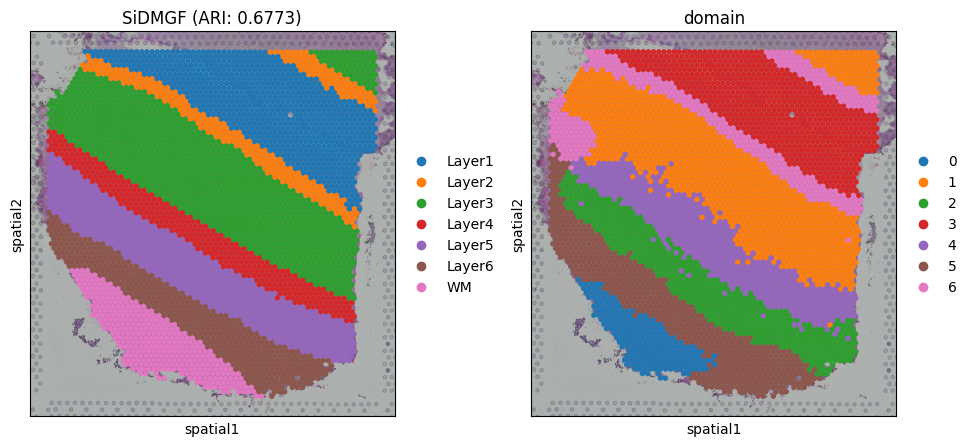

In [10]:
# save_dir = f'D:/st_projects/SiDMGF/result/DLPFC/{sample}/'
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)

adata.obs['domain'] = pd.Categorical(best_clusters)

plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.spatial(
    adata,
    img_key="hires",
    color=['ground_truth', 'domain'],
    title=f'SiDMGF (ARI: {ari_max:.4f})',
    show=True,
    size=1.5,
)

In [11]:
import ot

def refine_label(adata, radius=50, key='label'):
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values

    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')

    n_cell = distance.shape[0]

    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)

    new_type = [str(i) for i in list(new_type)]
    #adata.obs['label_refined'] = np.array(new_type)

    return new_type

In [12]:
from process.utils import BestMap

sc.set_figure_params(scanpy=True, dpi=80, dpi_save=600, frameon=True, vector_friendly=False, fontsize=12, figsize=(5, 4), color_map=None, format='pdf', facecolor=None, transparent=True, ipython_format='png2x')

new_type = refine_label(adata, 20, key='domain')
adata.obs["refined_pred"] = new_type
adata.obs["refined_pred"] = adata.obs["refined_pred"].astype('category')

adata.obs['pred'] = BestMap(pd.Categorical(adata.obs['ground_truth']).codes, pd.Categorical(adata.obs['domain']).codes)
adata.obs['pred'] = adata.obs['pred'].astype('category')

adata.obs['refined_pred'] = BestMap(pd.Categorical(adata.obs['ground_truth']).codes, pd.Categorical(adata.obs['refined_pred']).codes)
adata.obs['refined_pred'] = adata.obs['refined_pred'].astype('category')

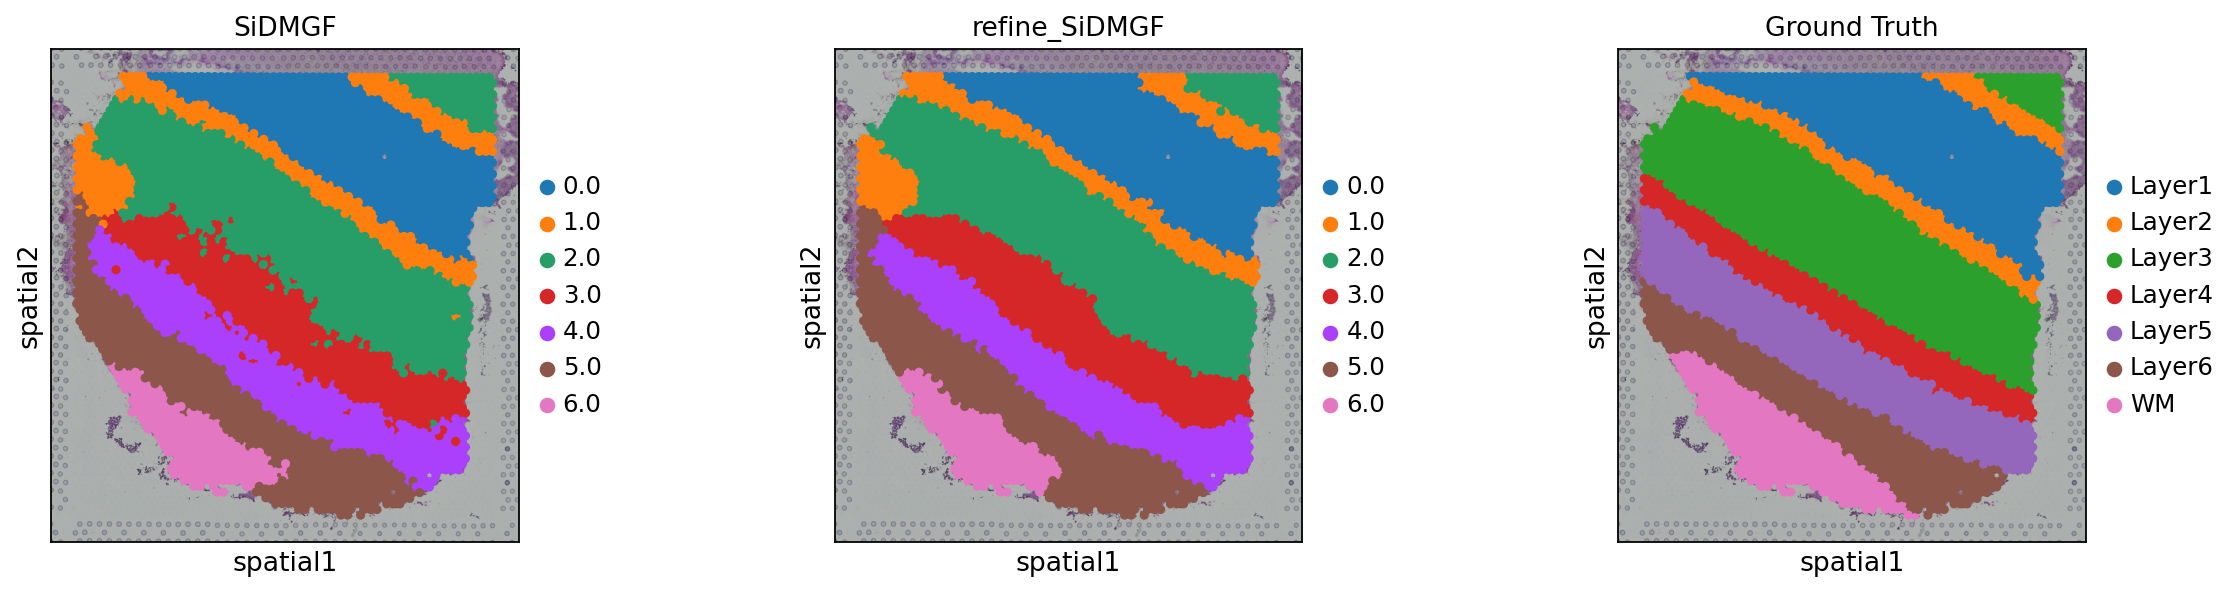

In [13]:
sc.pl.spatial(adata, color=['pred', 'refined_pred', 'ground_truth'], title=['SiDMGF', 'refine_SiDMGF', 'Ground Truth'], size=2)

In [14]:
ari_refine = adjusted_rand_score(adata.obs['ground_truth'], adata.obs['refined_pred'])
ari_refine

0.6836194744489461

In [15]:
from sklearn.metrics import normalized_mutual_info_score, f1_score

print(normalized_mutual_info_score(adata.obs['ground_truth'], adata.obs['pred']))
print(f1_score(pd.Categorical(adata.obs['ground_truth']).codes, pd.Categorical(adata.obs['pred']).codes, average='macro'))

0.7120374734760488
0.7734526263970521


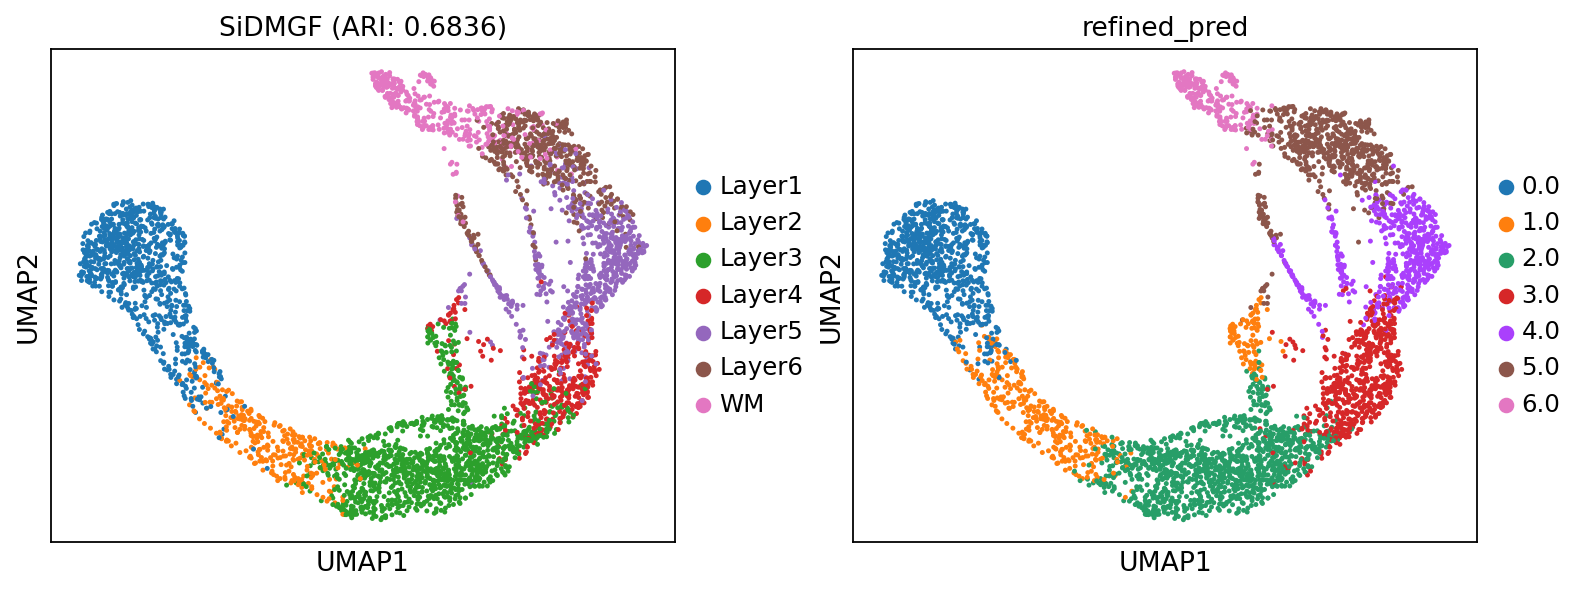

In [16]:
adata.obsm['embd'] = best_emb.cpu().detach().numpy()
sc.pp.neighbors(adata, use_rep='embd')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'refined_pred'], title=f'SiDMGF (ARI: {ari_refine:.4f})', size=20)

In [18]:
rec_exp = best_mean.cpu().detach().numpy()
adata.layers['SiDMGF'] = sp.csr_matrix(rec_exp)

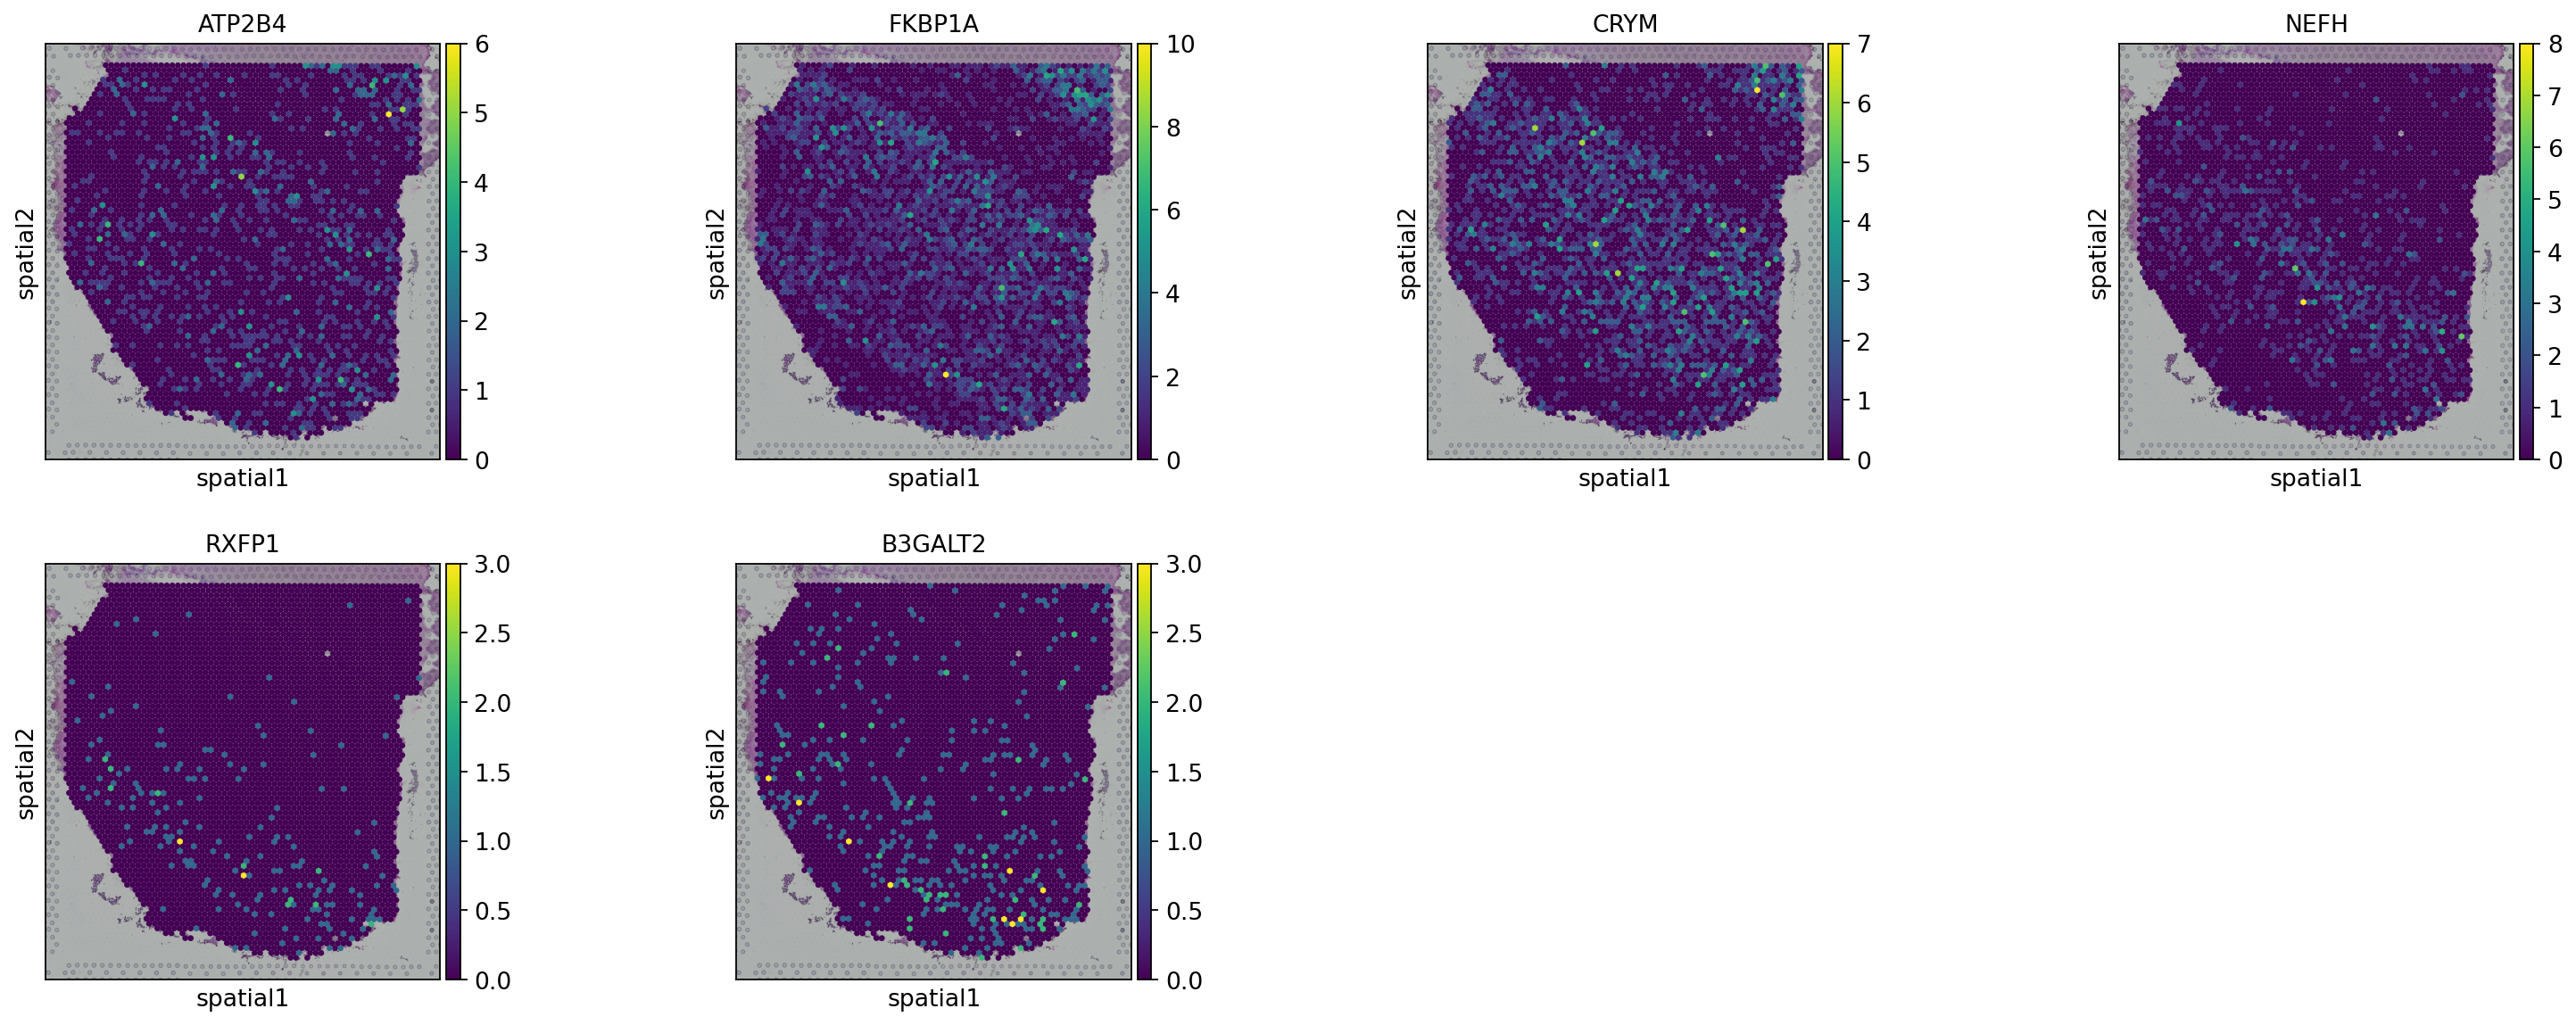

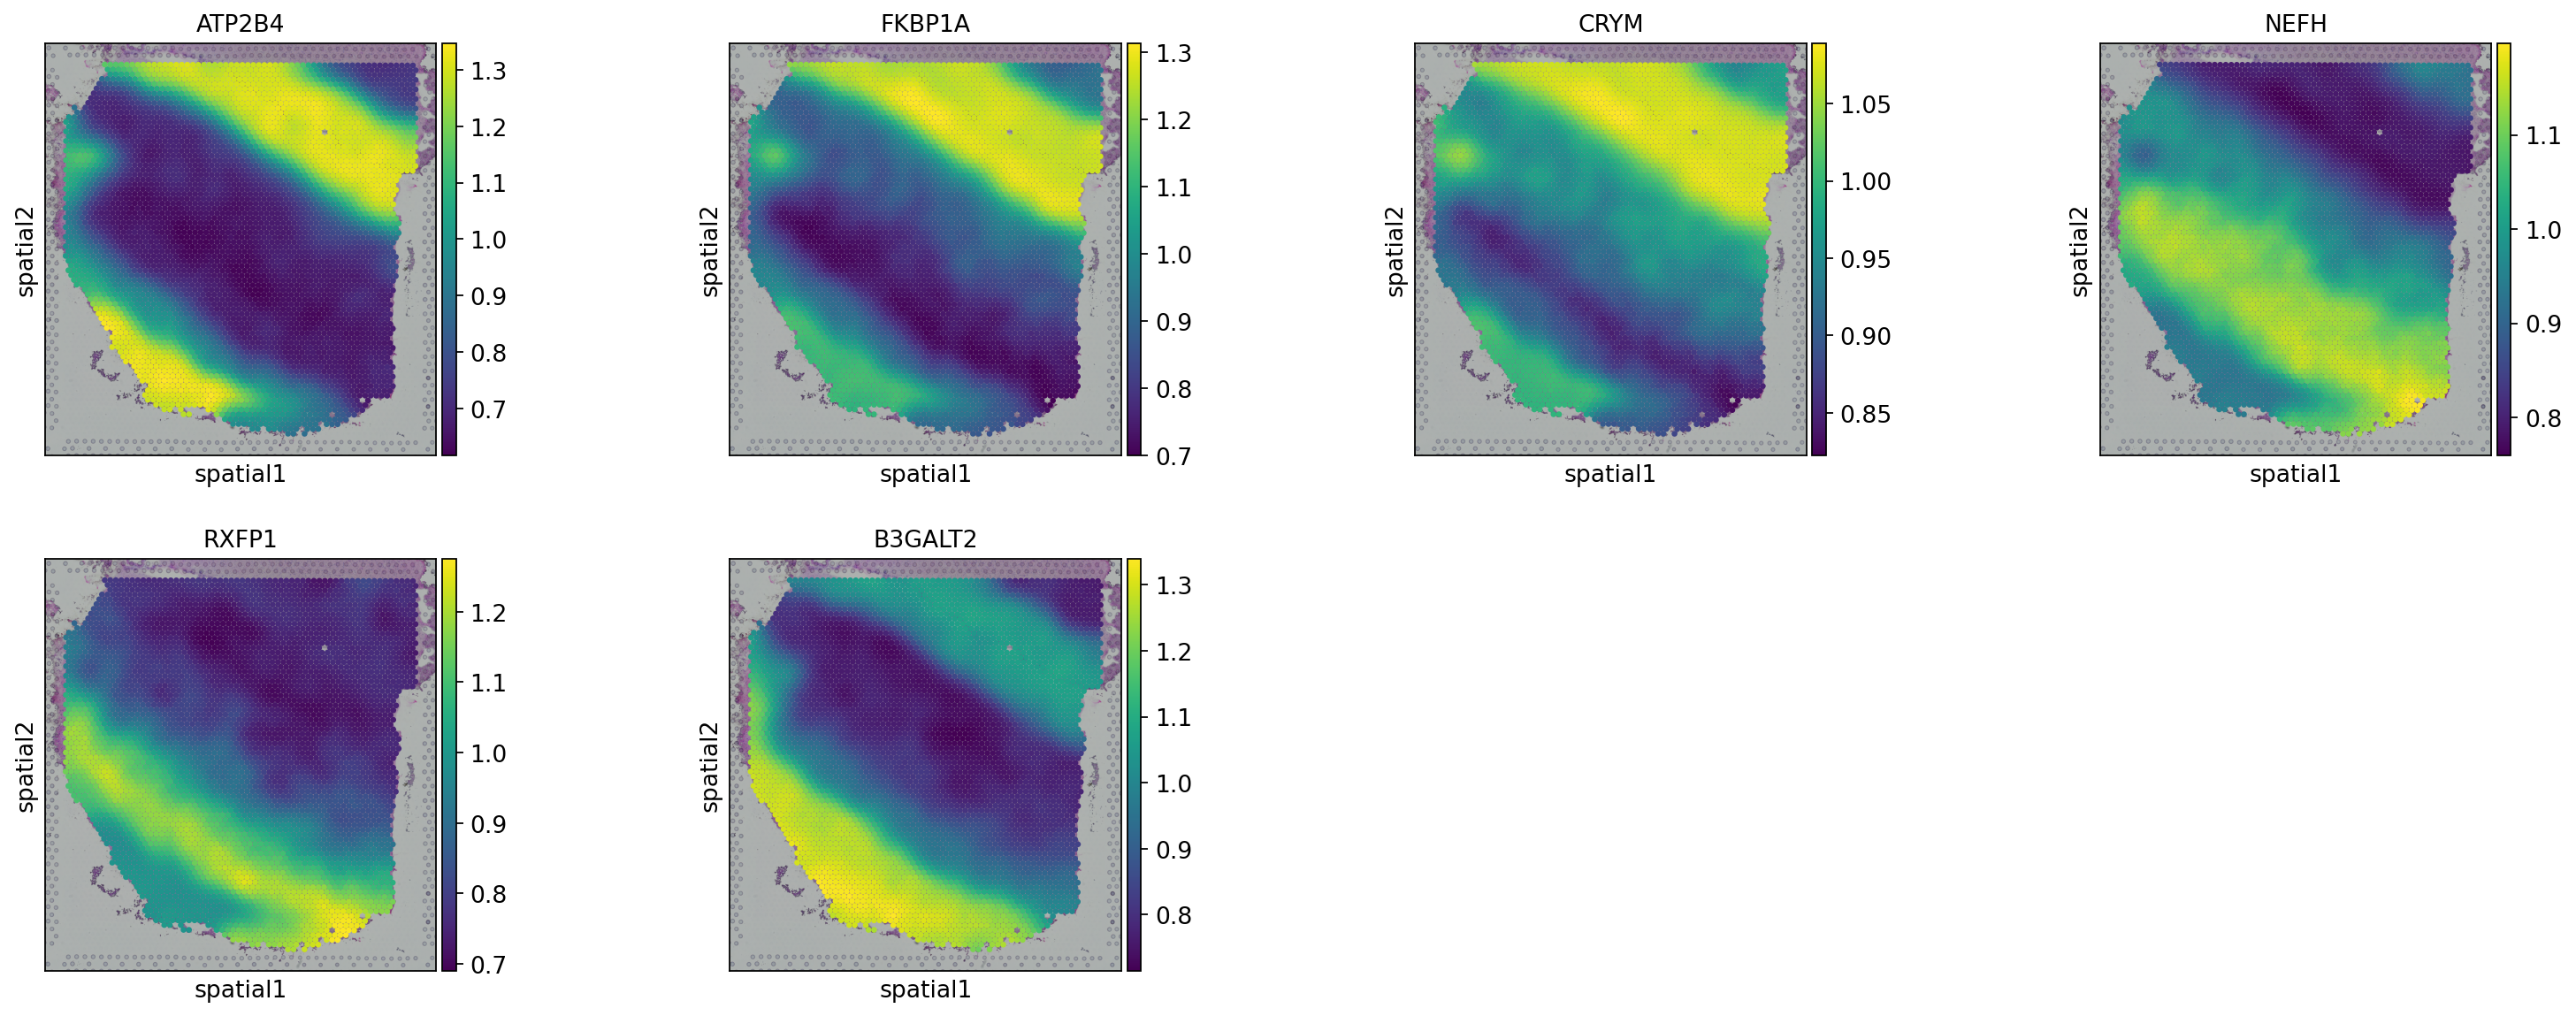

In [19]:
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=600, frameon=True, vector_friendly=True, fontsize=12, figsize=(5, 4), color_map=None, format='pdf', facecolor=None, transparent=True, ipython_format='png2x')

markers = ['ATP2B4', 'FKBP1A', 'CRYM', 'NEFH', 'RXFP1', 'B3GALT2']
marker_mucst = ['C1QL2', 'NTNG1', 'GABRA5', 'ACTA2']
sc.pl.spatial(adata, color=markers, layer='counts', size=1.5, save='exp_raw', groups=['2'])
sc.pl.spatial(adata, color=markers, layer='SiDMGF', size=1.5, save='exp_SiDMGF')

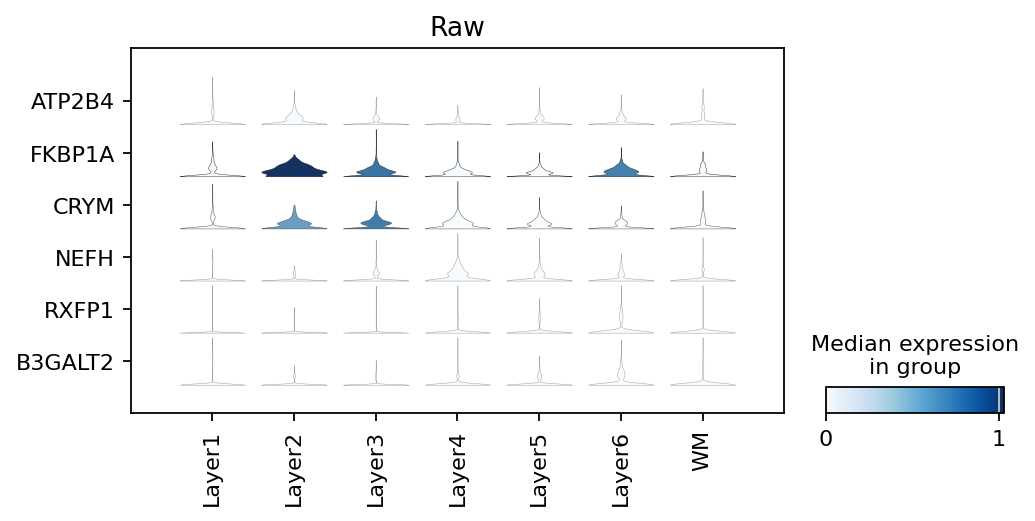

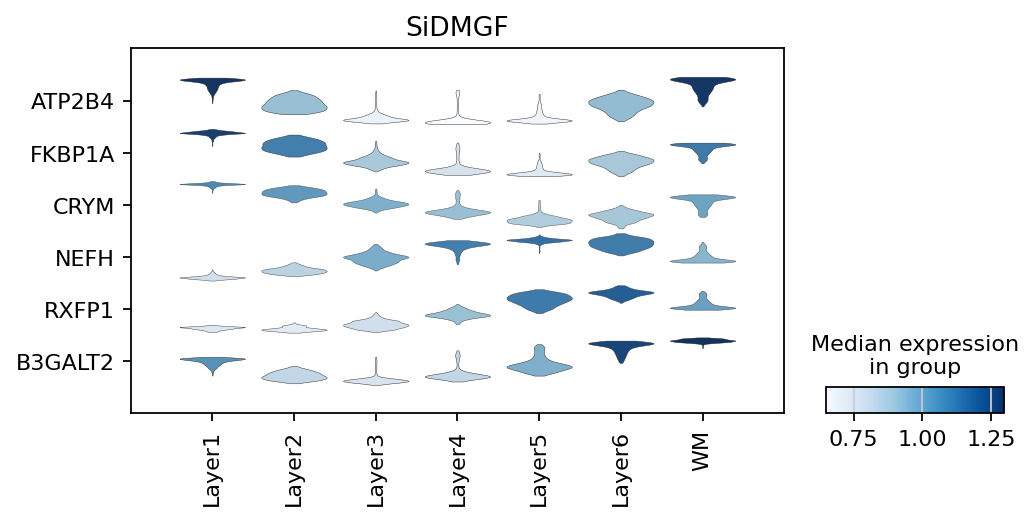

In [20]:
sc.pl.stacked_violin(adata, markers, title='Raw', groupby='ground_truth', swap_axes=True, figsize=[7, 3], show=True, save='stacked_violin_Raw')
# plt.savefig(savepath + 'stacked_violin_Raw.jpg', bbox_inches='tight', dpi=600)
# plt.show()

sc.pl.stacked_violin(adata, markers, layer='SiDMGF', title='SiDMGF', groupby='ground_truth', swap_axes=True, figsize=[7, 3], show=True, save='stacked_violin_SiDMGF')
# plt.savefig(savepath + 'stacked_violin_Spatial_MGCN.jpg', bbox_inches='tight', dpi=600)
# plt.show()